# Grokking em Redes Neurais: Conservação de Energia Modular ($x^2 + y^2 \\pmod p$)

Este notebook demonstra o fenômeno de **grokking** na tarefa de **Conservação de Energia Modular** sob duas arquiteturas distintas: um **Perceptron Multicamadas (MLP)** e um **Transformer Causal**. Esta tarefa possui uma forte conexão física com sistemas orbitais, mecânica clássica e mecânica quântica (degenerescência de estados de energia).

### O Problema
A rede recebe um par $(x, y)$ de inteiros no intervalo $[0, p-1]$ e deve prever o resultado da soma de seus quadrados módulo $p$:

$$c = (x^2 + y^2) \\pmod p$$

### Apelo Físico: Invariância Rotacional e Degenerescência
Na física contínua, a equação $x^2 + y^2 = R^2$ define órbitas circulares ou superfícies equipotenciais (conservação de energia e momento angular). No espaço discreto $\\mathbb{Z}_p$, a operação conserva essa simetria de forma modular. Para resolver essa tarefa e generalizar, a rede precisa agrupar os números de acordo com seus resíduos quadráticos. 

Elementos $x$ e $p-x$ possuem o mesmo quadrado módulo $p$ ($x^2 \\equiv (p-x)^2 \\pmod p$). Portanto, eles são **estados degenerados de energia**, devendo ser mapeados para embeddings equivalentes. Ao aplicar PCA sobre os embeddings aprendidos pós-grokking, devemos ver esses pares perfeitamente sobrepostos e as diferentes classes orbitais organizadas em anéis concêntricos.

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

# Configurar sementes para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: cpu


## PARTE A: O Perceptron Multicamadas (MLP)

### 1. Definição do Modelo MLP

Utilizamos um MLP composto por uma camada de embedding, concatenação das entradas, uma camada oculta linear com ativação GELU e uma camada de saída linear.

In [2]:
class ModularEnergyMLP(nn.Module):
    def __init__(self, p, embed_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Embedding(p, embed_dim)
        self.fc1 = nn.Linear(embed_dim * 2, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, p)
        
    def forward(self, x):
        # x shape: (B, 2)
        e = self.embed(x) # (B, 2, embed_dim)
        e = e.view(e.shape[0], -1) # (B, 2 * embed_dim)
        h = self.act(self.fc1(e))
        logits = self.fc2(h)
        return logits

### 2. Geração e Divisão de Dados (MLP)

Definimos $p = 59$. O conjunto total possui $p^2 = 3481$ pares. Dividimos os dados utilizando uma fração de treino de $45\\%$ ($1566$ amostras) e $55\\%$ para validação ($1915$ amostras).

In [3]:
p = 59
train_fraction_mlp = 0.45

def get_data_mlp(p, train_fraction):
    x, y = [], []
    for a in range(p):
        for b in range(p):
            x.append([a, b])
            y.append((a**2 + b**2) % p)
            
    x = torch.tensor(x, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.long)
    
    num_samples = len(x)
    indices = np.random.permutation(num_samples)
    split_idx = int(num_samples * train_fraction)
    
    train_idx = indices[:split_idx]
    val_idx = indices[split_idx:]
    
    return x[train_idx], y[train_idx], x[val_idx], y[val_idx]

train_x_mlp, train_y_mlp, val_x_mlp, val_y_mlp = get_data_mlp(p, train_fraction_mlp)
print(f"Tamanho do conjunto de Treino (MLP): {len(train_x_mlp)}")
print(f"Tamanho do conjunto de Validação (MLP): {len(val_x_mlp)}")

Tamanho do conjunto de Treino (MLP): 1566
Tamanho do conjunto de Validação (MLP): 1915


### 3. Loop de Treinamento (MLP)

Treinamos o modelo utilizando AdamW com regularização por decaimento de pesos $\\lambda = 1.0$ e taxa de aprendizado $\\eta = 10^{-3}$.

In [4]:
set_seed(42)
model_mlp = ModularEnergyMLP(p=p, embed_dim=64, hidden_dim=128).to(device)
optimizer_mlp = optim.AdamW(model_mlp.parameters(), lr=1e-3, weight_decay=1.0)
criterion = nn.CrossEntropyLoss()

train_x_mlp, train_y_mlp = train_x_mlp.to(device), train_y_mlp.to(device)
val_x_mlp, val_y_mlp = val_x_mlp.to(device), val_y_mlp.to(device)

history_mlp = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'weight_l2': []
}

epochs = 10000
for epoch in range(1, epochs + 1):
    model_mlp.train()
    optimizer_mlp.zero_grad()
    logits = model_mlp(train_x_mlp)
    loss = criterion(logits, train_y_mlp)
    loss.backward()
    optimizer_mlp.step()
    
    model_mlp.eval()
    with torch.no_grad():
        train_preds = logits.argmax(dim=-1)
        train_acc = (train_preds == train_y_mlp).float().mean().item()
        
        val_logits = model_mlp(val_x_mlp)
        val_loss = criterion(val_logits, val_y_mlp).item()
        val_preds = val_logits.argmax(dim=-1)
        val_acc = (val_preds == val_y_mlp).float().mean().item()
        
        w_norm = sum(p.pow(2).sum() for p in model_mlp.parameters()).sqrt().item()
        
    history_mlp['train_loss'].append(loss.item())
    history_mlp['train_acc'].append(train_acc * 100)
    history_mlp['val_loss'].append(val_loss)
    history_mlp['val_acc'].append(val_acc * 100)
    history_mlp['weight_l2'].append(w_norm)
    
    if epoch % 1000 == 0 or epoch == 1:
        print(f"Época {epoch:5d}/{epochs} | Treino Loss: {loss.item():.4f} Acc: {train_acc*100:6.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:6.2f}%")
        
    if train_acc > 0.999 and val_acc > 0.98:
        print(f"Grokking atingido na época {epoch}!")
        break

Época     1/10000 | Treino Loss: 4.0900 Acc:   1.53% | Val Loss: 4.1015 Acc:   1.57%


Época  1000/10000 | Treino Loss: 0.0265 Acc: 100.00% | Val Loss: 1.8222 Acc:  63.60%


Época  2000/10000 | Treino Loss: 0.0101 Acc: 100.00% | Val Loss: 0.5421 Acc:  87.10%


Época  3000/10000 | Treino Loss: 0.0053 Acc: 100.00% | Val Loss: 0.2726 Acc:  93.26%


Época  4000/10000 | Treino Loss: 0.0031 Acc: 100.00% | Val Loss: 0.1749 Acc:  96.97%


Época  5000/10000 | Treino Loss: 0.0019 Acc: 100.00% | Val Loss: 0.1298 Acc:  97.96%
Grokking atingido na época 5005!


### 4. Resultados Gráficos: Curvas de Treinamento (MLP)

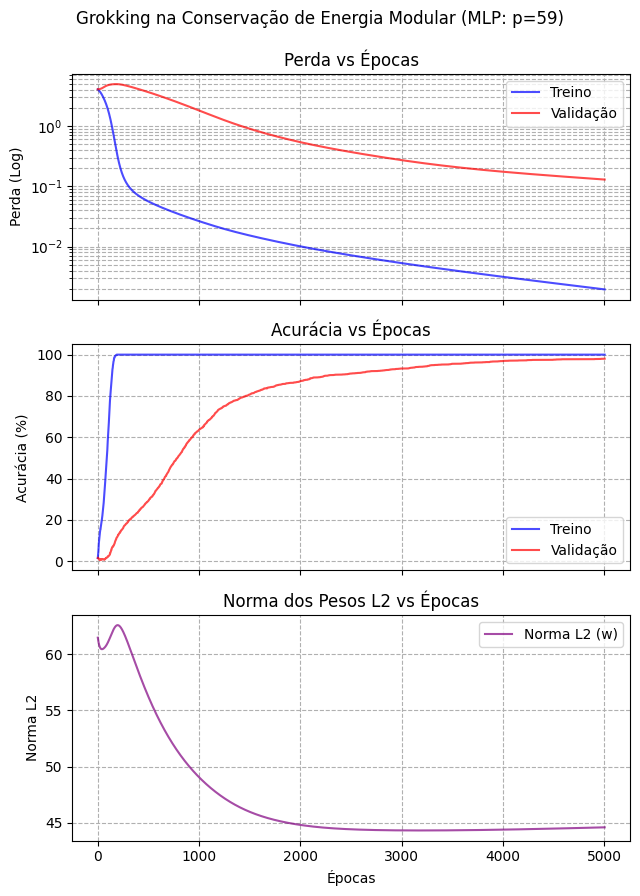

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6.5, 9.0), sharex=True)

# 1. Perda
ax1.plot(history_mlp['train_loss'], label='Treino', color='blue', alpha=0.7)
ax1.plot(history_mlp['val_loss'], label='Validação', color='red', alpha=0.7)
ax1.set_yscale('log')
ax1.set_title('Perda vs Épocas')
ax1.set_ylabel('Perda (Log)')
ax1.legend()
ax1.grid(True, which='both', ls='--')

# 2. Acurácia
ax2.plot(history_mlp['train_acc'], label='Treino', color='blue', alpha=0.7)
ax2.plot(history_mlp['val_acc'], label='Validação', color='red', alpha=0.7)
ax2.set_title('Acurácia vs Épocas')
ax2.set_ylabel('Acurácia (%)')
ax2.legend()
ax2.grid(True, ls='--')

# 3. Norma L2
ax3.plot(history_mlp['weight_l2'], label='Norma L2 (w)', color='purple', alpha=0.7)
ax3.set_title('Norma dos Pesos L2 vs Épocas')
ax3.set_xlabel('Épocas')
ax3.set_ylabel('Norma L2')
ax3.legend()
ax3.grid(True, ls='--')

plt.suptitle('Grokking na Conservação de Energia Modular (MLP: p=59)', fontsize=12, y=0.99)
plt.tight_layout()
os.makedirs('../paper', exist_ok=True)
plt.savefig('../paper/grokking_energy.png', dpi=300)
plt.show()

### 5. Projeção de Embeddings (MLP: Órbitas e Degenerescência)

Extraímos a camada de embedding do modelo treinado e aplicamos PCA de 2 componentes. Colorimos os pontos de acordo com seu resíduo quadrático $x^2 \\pmod p$.

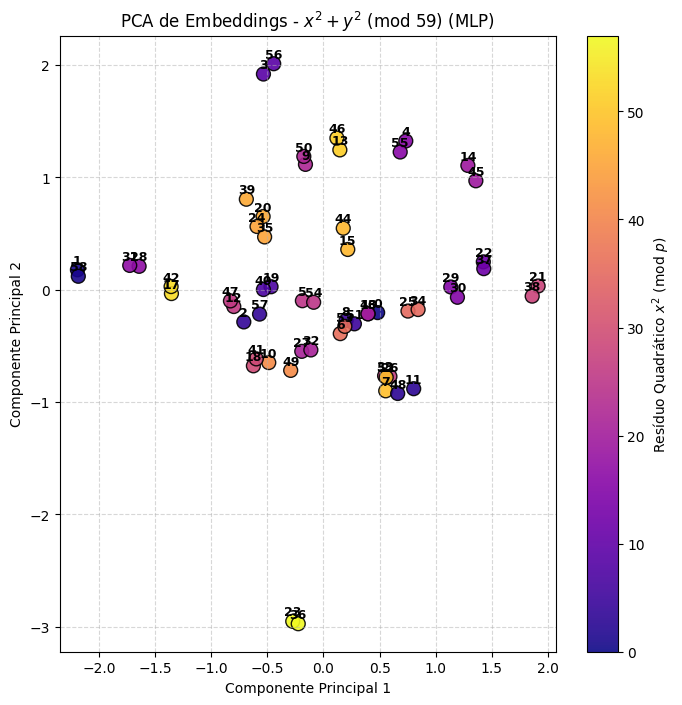

In [6]:
model_mlp.eval()
embeddings = model_mlp.embed.weight.detach().cpu().numpy()
pca = PCA(n_components=2)
embed_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 8))
colors = [(x**2) % p for x in range(p)]
scatter = plt.scatter(embed_pca[:, 0], embed_pca[:, 1], c=colors, cmap='plasma', s=100, edgecolors='black', alpha=0.9)

for i in range(p):
    plt.annotate(str(i), (embed_pca[i, 0], embed_pca[i, 1]), fontsize=9, xytext=(0, 4), textcoords='offset points', ha='center', weight='bold')
    
plt.colorbar(scatter, label='Resíduo Quadrático $x^2 \\ (\\text{mod } p)$')
plt.title(f'PCA de Embeddings - $x^2 + y^2 \\ (\\text{{mod }} {p})$ (MLP)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.savefig('../paper/grokking_energy_embeddings.png', dpi=300)
plt.show()

## PARTE B: O Transformer Causal

### 6. Definição do Modelo Transformer

Utilizamos um Transformer decoder-only de 1 camada que processa sequências de tamanho 3 na forma $[x, y, =]$, realizando a predição na posição do token ``=''.

In [7]:
class ModularEnergyTransformer(nn.Module):
    def __init__(self, p, embed_dim, num_heads, hidden_dim):
        super().__init__()
        self.num_tokens = p + 1  # p operandos + 1 token '=' (representado por p)
        self.embed = nn.Embedding(self.num_tokens, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(3, embed_dim))
        
        # Causal Attention
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.v_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        
        # MLP
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        
        # LayerNorms
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.unembed = nn.Linear(embed_dim, p, bias=False)
        
    def forward(self, x):
        B = x.shape[0]
        h = self.embed(x) + self.pos_embed.unsqueeze(0)
        
        h_norm = self.ln1(h)
        q = self.q_proj(h_norm)
        k = self.k_proj(h_norm)
        v = self.v_proj(h_norm)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) / (q.shape[-1] ** 0.5)
        mask = torch.triu(torch.ones(3, 3, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask.unsqueeze(0), -1e9)
        
        weights = torch.softmax(scores, dim=-1)
        attn_out = torch.matmul(weights, v)
        attn_out = self.out_proj(attn_out)
        
        h = h + attn_out
        
        h_norm = self.ln2(h)
        mlp_out = self.fc2(self.act(self.fc1(h_norm)))
        h = h + mlp_out
        
        logits = self.unembed(h[:, 2, :])
        return logits

### 7. Geração e Divisão de Dados (Transformer)

Utilizamos uma fração de treino de $40\\%$ ($1392$ amostras) e validação de $60\\%$ ($2089$ amostras).

In [8]:
train_fraction_tf = 0.40

def get_data_tf(p, train_fraction):
    x, y = [], []
    for a in range(p):
        for b in range(p):
            x.append([a, b, p]) # Formato [x, y, =]
            y.append((a**2 + b**2) % p)
            
    x = torch.tensor(x, dtype=torch.long)
    y = torch.tensor(y, dtype=torch.long)
    
    num_samples = len(x)
    indices = np.random.permutation(num_samples)
    split_idx = int(num_samples * train_fraction)
    
    train_idx = indices[:split_idx]
    val_idx = indices[split_idx:]
    
    return x[train_idx], y[train_idx], x[val_idx], y[val_idx]

train_x_tf, train_y_tf, val_x_tf, val_y_tf = get_data_tf(p, train_fraction_tf)
print(f"Tamanho do conjunto de Treino (Transformer): {len(train_x_tf)}")
print(f"Tamanho do conjunto de Validação (Transformer): {len(val_x_tf)}")

Tamanho do conjunto de Treino (Transformer): 1392
Tamanho do conjunto de Validação (Transformer): 2089


### 8. Loop de Treinamento (Transformer)

Treinamos o Transformer utilizando o otimizador AdamW com decaimento de pesos $\\lambda = 1.0$ e taxa de aprendizado $\\eta = 10^{-3}$.

In [9]:
set_seed(42)
model_tf = ModularEnergyTransformer(p=p, embed_dim=64, num_heads=2, hidden_dim=128).to(device)
optimizer_tf = optim.AdamW(model_tf.parameters(), lr=1e-3, weight_decay=1.0)
criterion = nn.CrossEntropyLoss()

train_x_tf, train_y_tf = train_x_tf.to(device), train_y_tf.to(device)
val_x_tf, val_y_tf = val_x_tf.to(device), val_y_tf.to(device)

history_tf = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'weight_l2': []
}

epochs_tf = 4000
for epoch in range(1, epochs_tf + 1):
    model_tf.train()
    optimizer_tf.zero_grad()
    logits = model_tf(train_x_tf)
    loss = criterion(logits, train_y_tf)
    loss.backward()
    optimizer_tf.step()
    
    model_tf.eval()
    with torch.no_grad():
        train_preds = logits.argmax(dim=-1)
        train_acc = (train_preds == train_y_tf).float().mean().item()
        
        val_logits = model_tf(val_x_tf)
        val_loss = criterion(val_logits, val_y_tf).item()
        val_preds = val_logits.argmax(dim=-1)
        val_acc = (val_preds == val_y_tf).float().mean().item()
        
        w_norm = sum(p.pow(2).sum() for p in model_tf.parameters()).sqrt().item()
        
    history_tf['train_loss'].append(loss.item())
    history_tf['train_acc'].append(train_acc * 100)
    history_tf['val_loss'].append(val_loss)
    history_tf['val_acc'].append(val_acc * 100)
    history_tf['weight_l2'].append(w_norm)
    
    if epoch % 500 == 0 or epoch == 1:
        print(f"Época {epoch:5d}/{epochs_tf} | Treino Loss: {loss.item():.4f} Acc: {train_acc*100:6.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:6.2f}%")
        
    if train_acc > 0.999 and val_acc > 0.98:
        print(f"Grokking atingido na época {epoch}!")
        break

Época     1/4000 | Treino Loss: 4.4747 Acc:   1.65% | Val Loss: 4.4159 Acc:   1.44%


Época   500/4000 | Treino Loss: 0.0182 Acc: 100.00% | Val Loss: 0.7231 Acc:  87.12%


Época  1000/4000 | Treino Loss: 0.0095 Acc: 100.00% | Val Loss: 0.1159 Acc:  97.08%


Grokking atingido na época 1321!


### 9. Resultados Gráficos: Curvas de Treinamento (Transformer)

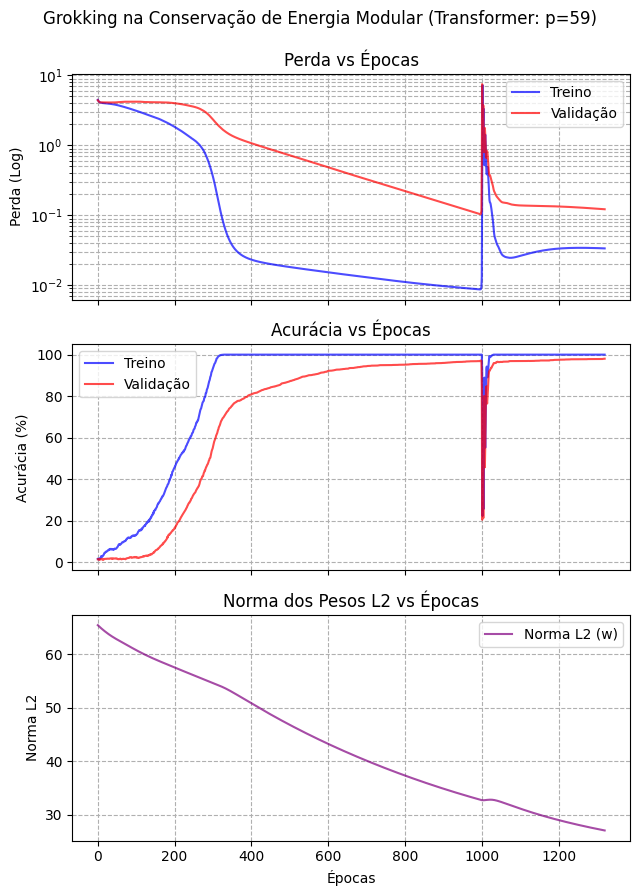

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6.5, 9.0), sharex=True)

# 1. Perda
ax1.plot(history_tf['train_loss'], label='Treino', color='blue', alpha=0.7)
ax1.plot(history_tf['val_loss'], label='Validação', color='red', alpha=0.7)
ax1.set_yscale('log')
ax1.set_title('Perda vs Épocas')
ax1.set_ylabel('Perda (Log)')
ax1.legend()
ax1.grid(True, which='both', ls='--')

# 2. Acurácia
ax2.plot(history_tf['train_acc'], label='Treino', color='blue', alpha=0.7)
ax2.plot(history_tf['val_acc'], label='Validação', color='red', alpha=0.7)
ax2.set_title('Acurácia vs Épocas')
ax2.set_ylabel('Acurácia (%)')
ax2.legend()
ax2.grid(True, ls='--')

# 3. Norma L2
ax3.plot(history_tf['weight_l2'], label='Norma L2 (w)', color='purple', alpha=0.7)
ax3.set_title('Norma dos Pesos L2 vs Épocas')
ax3.set_xlabel('Épocas')
ax3.set_ylabel('Norma L2')
ax3.legend()
ax3.grid(True, ls='--')

plt.suptitle('Grokking na Conservação de Energia Modular (Transformer: p=59)', fontsize=12, y=0.99)
plt.tight_layout()
plt.savefig('../paper/grokking_energy_transformer.png', dpi=300)
plt.show()

### 10. Projeção de Embeddings (Transformer: Órbitas e Degenerescência)

Extraímos a camada de embedding do Transformer e realizamos a projeção PCA de 2 componentes.

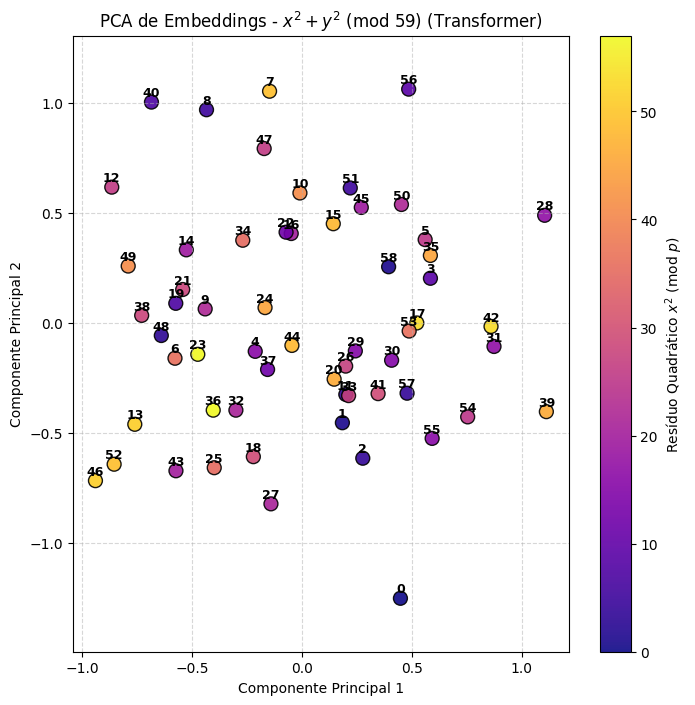

In [11]:
model_tf.eval()
embeddings_tf = model_tf.embed.weight.detach().cpu().numpy()[:p] # Ignoramos o token '=' no índice p
pca_tf = PCA(n_components=2)
embed_pca_tf = pca_tf.fit_transform(embeddings_tf)

plt.figure(figsize=(8, 8))
colors = [(x**2) % p for x in range(p)]
scatter = plt.scatter(embed_pca_tf[:, 0], embed_pca_tf[:, 1], c=colors, cmap='plasma', s=100, edgecolors='black', alpha=0.9)

for i in range(p):
    plt.annotate(str(i), (embed_pca_tf[i, 0], embed_pca_tf[i, 1]), fontsize=9, xytext=(0, 4), textcoords='offset points', ha='center', weight='bold')
    
plt.colorbar(scatter, label='Resíduo Quadrático $x^2 \\ (\\text{mod } p)$')
plt.title(f'PCA de Embeddings - $x^2 + y^2 \\ (\\text{{mod }} {p})$ (Transformer)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.savefig('../paper/grokking_energy_transformer_embeddings.png', dpi=300)
plt.show()